### This notebook compute "VSB3. Index of environmental quality of surface water resources -ICARHS (Cat1: Population and recreational)" indicator for the 27 basins of IKI Project

Spanish: Indice de calidad ambiental de los recursos hidricos superficiales -ICARHS (Cat1: Poblacional y recreacional)

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/8/2-26 by Sophia (sbakar@rti.org)

**Status:** Complete and loaded in SQLite database for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad

**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib
 
**Inputs:**   Shapefile of COMIDs and districts, ICARHS: Índice de la calidad ambiental de los recursos hídricos superficiales, Cat1.

**Outputs:** 
 
**Assumptions:** COMIDs with no values for Category 1 are populated with NaN. In this case we keep 0 because it is included in the categorization process.

**N/A Handling:** Assign NaN where no score is present. A zero corresponds with an index of P.  
 
**Future work:** 
 
**Notes:** 

General Methodolgy:  
1. Filter for Categoria 1 A2.  
2. Extract the score and categorize it into different levels: 1 for E, 0.75 for B, 0.5 for R, 0.25 for M, and 0 for P.  
3. Reproject crs to match the COMIDs, then spatially join to assign scores to COMIDs. 
4. If multiple scores exist within a COMID, caluclate the mean value. If no scores exist within a COMID, assign NaN. 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 303 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

# env_qual_index_shapefile = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/3_HIDROLOGIA_HYDROGRAPHY/Datos_ANA/CalidadAguaICARHS/CalidadAguaICARHS.shp'
env_qual_index_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\CalidadAguaICARHS\CalidadAguaICARHS.shp"

In [5]:
#read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

env_qual_index = gpd.read_file(env_qual_index_shapefile).to_crs('EPSG:32718')

#Depending on input data, count/sum points per basin
# #determine best way to disaggregate data givent the fact that the index would be very location dependent. I.e. just because one location in one stream in the basin has a certain value, it would not apply to the rest of the streams in the basin.
#subbasins_gdf['env_qual_index'] = subbasins_gdf['COMID'].map(env_qual_index.set_index('COMID')['env_qual_index'])

#filter out only those with CATEGORIA= 3
env_qual_index_cat = env_qual_index[env_qual_index['CATEGORIA'] == 'Categoría 1 A2']

In [6]:
# CALCULATION OF INDICATOR
#ICONO column includes a three-letter code representing environmental quality index
#extract the last three letters of the ICONO column from env_qual_index and create a new column with these values
env_qual_index_cat['score'] = env_qual_index_cat['ICONO'].str[-3:-2]

def score_to_value(score):
    score_map = {'E': 1, 'B': 0.75, 'R': 0.5, 'M': 0.25, 'P': 0}
    total = 0
    for letter in score:
        total += score_map.get(letter, 0)
    return total / len(score)

env_qual_index_cat['env_qual_index'] = env_qual_index_cat['score'].apply(score_to_value)

# match CRS
env_qual_index_cat = env_qual_index_cat.to_crs(subbasins_gdf.crs)

# spatial join to assign COMID
env_qual_index_cat = gpd.sjoin(
    env_qual_index_cat,
    subbasins_gdf[['COMID', 'geometry']],
    how='left',
    predicate='intersects'
)

C:\Users\sbakar\AppData\Roaming\Python\Python312\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\sbakar\AppData\Roaming\Python\Python312\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
# Group by COMID with explicit NaN vs 0 handling
env_qual_index_cat_grouped = (
    env_qual_index_cat
    .groupby('COMID', as_index=False)
    .agg(
        env_qual_index=('env_qual_index', 'mean'),
        n_points=('env_qual_index', 'count')
    )
)

# Explicit rule:
# - n_points == 0 → no data → NaN
# - env_qual_index == 0 → valid "pésimo"
env_qual_index_cat_grouped.loc[
    env_qual_index_cat_grouped['n_points'] == 0,
    'env_qual_index'
] = np.nan

# round valid values only
env_qual_index_cat_grouped['env_qual_index'] = (
    env_qual_index_cat_grouped['env_qual_index'].round(2)
)

# map back to subbasins
subbasins_gdf['env_qual_index'] = subbasins_gdf['COMID'].map(
    env_qual_index_cat_grouped.set_index('COMID')['env_qual_index']
)


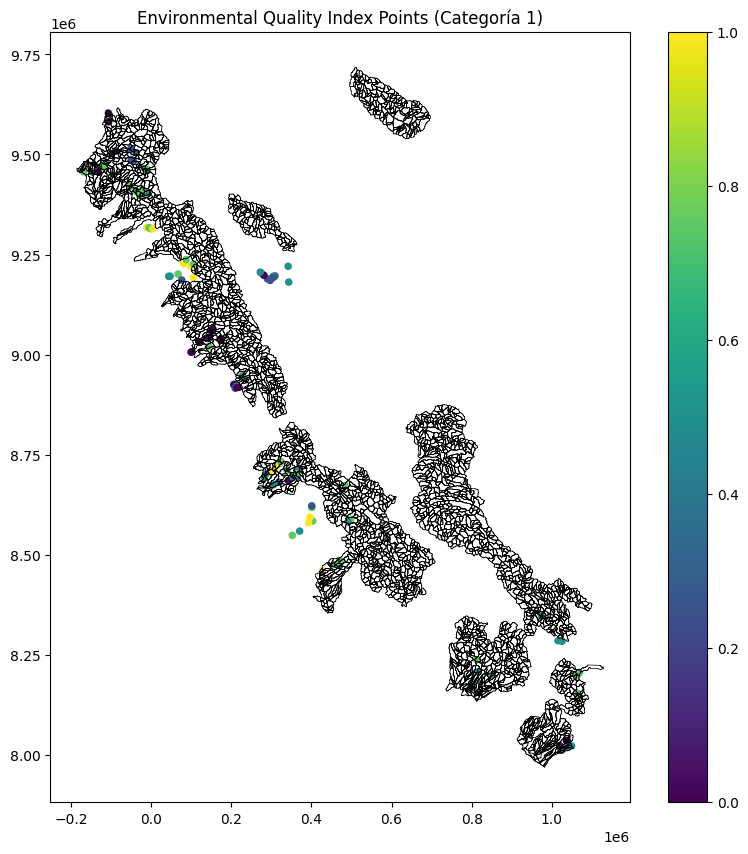

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
subbasins_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
env_qual_index_cat.plot(
    column='env_qual_index',
    ax=ax,
    legend=True,
    cmap='viridis',
    markersize=20
)
ax.set_title('Environmental Quality Index Points (Categoría 1)')
plt.show()

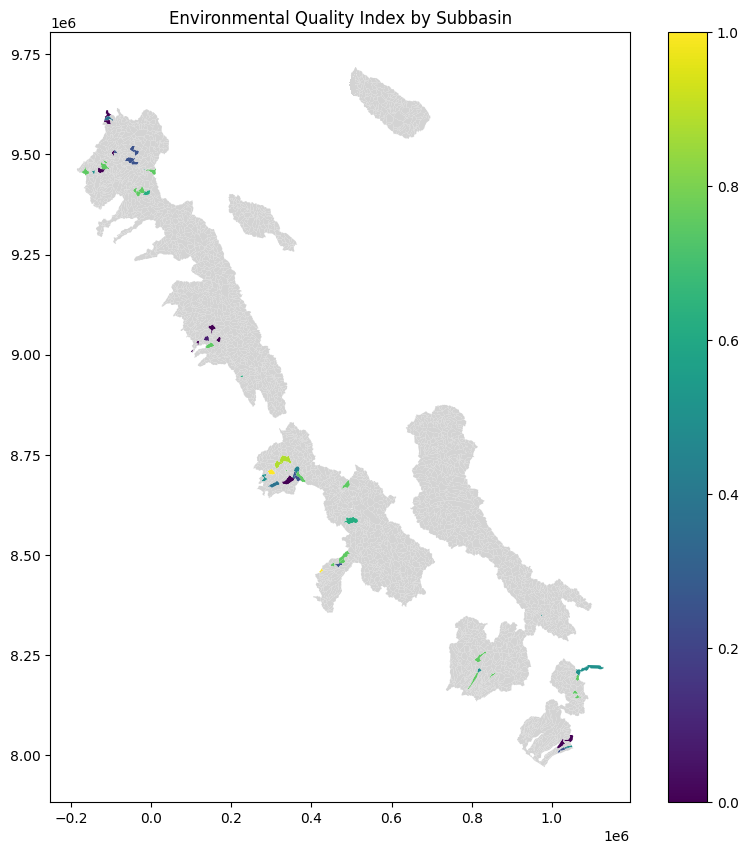

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
subbasins_gdf.plot(
    column='env_qual_index',
    ax=ax,
    cmap='viridis',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)
ax.set_title('Environmental Quality Index by Subbasin')
plt.show()

In [10]:
# insert results into the database 
insert_data= subbasins_gdf #COMID 
value_column= 'env_qual_index' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [11]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['env_qual_index']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 303  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  env_qual_index
0    min             0.0
1    max             1.0
2  count            62.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()